In [1]:
# ============================================================
# CELL 1: Cài đặt và import thư viện
# ============================================================
!pip install imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ Import thư viện thành công!")

✅ Import thư viện thành công!


In [2]:
# ============================================================
# CELL 2: Kết nối Google Drive và đọc dữ liệu
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os
import glob

# Đường dẫn tới folder chứa dataset
DATA_PATH = '/content/drive/MyDrive/IDS_Dataset/'

# Tìm tất cả file CSV
csv_files = glob.glob(DATA_PATH + '*.csv')
print(f"📁 Tìm thấy {len(csv_files)} file CSV:")
for f in csv_files:
    print(f"   - {os.path.basename(f)}")

Mounted at /content/drive
📁 Tìm thấy 8 file CSV:
   - Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
   - Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
   - Friday-WorkingHours-Morning.pcap_ISCX.csv
   - Monday-WorkingHours.pcap_ISCX.csv
   - Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
   - Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
   - Tuesday-WorkingHours.pcap_ISCX.csv
   - Wednesday-workingHours.pcap_ISCX.csv


In [3]:
# ============================================================
# CELL 3: Gộp tất cả CSV thành 1 DataFrame lớn
# ============================================================
print("⏳ Đang đọc dữ liệu, vui lòng chờ...")

dfs = []
for file in csv_files:
    df_temp = pd.read_csv(file, encoding='utf-8', low_memory=False)
    dfs.append(df_temp)
    print(f"   ✅ {os.path.basename(file)} — {df_temp.shape[0]:,} dòng")

# Gộp lại
df = pd.concat(dfs, ignore_index=True)
print(f"\n🎉 Tổng cộng: {df.shape[0]:,} dòng | {df.shape[1]} cột")
print(f"📊 Bộ nhớ sử dụng: {df.memory_usage().sum() / 1024**2:.1f} MB")

⏳ Đang đọc dữ liệu, vui lòng chờ...
   ✅ Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv — 225,745 dòng
   ✅ Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv — 286,467 dòng
   ✅ Friday-WorkingHours-Morning.pcap_ISCX.csv — 191,033 dòng
   ✅ Monday-WorkingHours.pcap_ISCX.csv — 529,918 dòng
   ✅ Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv — 288,602 dòng
   ✅ Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv — 170,366 dòng
   ✅ Tuesday-WorkingHours.pcap_ISCX.csv — 445,909 dòng
   ✅ Wednesday-workingHours.pcap_ISCX.csv — 692,703 dòng

🎉 Tổng cộng: 2,830,743 dòng | 79 cột
📊 Bộ nhớ sử dụng: 1706.2 MB


In [17]:
# ============================================================
# CELL 4: Làm sạch dữ liệu (Data Cleaning)
# ============================================================

print("🧹 Bắt đầu làm sạch dữ liệu...")
print(f"   Shape ban đầu: {df.shape}")

# 1. Xóa khoảng trắng thừa ở tên cột
df.columns = df.columns.str.strip()
print("   ✅ Đã xóa khoảng trắng tên cột")

# 2. Thay thế giá trị vô cực (inf) và NaN bằng median
df.replace([np.inf, -np.inf], np.nan, inplace=True)
for col in df.select_dtypes(include=[np.number]).columns:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
print("   ✅ Đã xử lý giá trị NaN và Inf")

# 3. Xóa các cột có variance = 0 (không mang thông tin gì)
before = df.shape[1]
numeric_cols = df.select_dtypes(include=[np.number]).columns
zero_var_cols = [col for col in numeric_cols if df[col].var() == 0]
df.drop(columns=zero_var_cols, inplace=True)
print(f"   ✅ Đã xóa {len(zero_var_cols)} cột zero-variance: {zero_var_cols}")

# 4. Xóa dòng trùng lặp
before_rows = df.shape[0]
df.drop_duplicates(inplace=True)
after_rows = df.shape[0]
print(f"   ✅ Đã xóa {before_rows - after_rows:,} dòng trùng lặp")

print(f"\n📊 Shape sau khi làm sạch: {df.shape}")

🧹 Bắt đầu làm sạch dữ liệu...
   Shape ban đầu: (2830743, 79)
   ✅ Đã xóa khoảng trắng tên cột
   ✅ Đã xử lý giá trị NaN và Inf
   ✅ Đã xóa 8 cột zero-variance: ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
   ✅ Đã xóa 308,381 dòng trùng lặp

📊 Shape sau khi làm sạch: (2522362, 71)


In [18]:
# ============================================================
# CELL 5: Tối ưu bộ nhớ bằng cách downcast kiểu dữ liệu
# ============================================================

print(f"💾 Bộ nhớ trước khi tối ưu: {df.memory_usage().sum() / 1024**2:.1f} MB")

# Downcast số nguyên
for col in df.select_dtypes(include=['int64']).columns:
    df[col] = pd.to_numeric(df[col], downcast='unsigned')

# Downcast số thực
for col in df.select_dtypes(include=['float64']).columns:
    df[col] = pd.to_numeric(df[col], downcast='float')

print(f"💾 Bộ nhớ sau khi tối ưu:  {df.memory_usage().sum() / 1024**2:.1f} MB")
print("✅ Tối ưu bộ nhớ thành công!")

💾 Bộ nhớ trước khi tối ưu: 1385.6 MB
💾 Bộ nhớ sau khi tối ưu:  839.5 MB
✅ Tối ưu bộ nhớ thành công!


📊 Phân bố nhãn (Label):
Label
BENIGN                        2096484
DoS Hulk                       172849
DDoS                           128016
PortScan                        90819
DoS GoldenEye                   10286
FTP-Patator                      5933
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1953
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


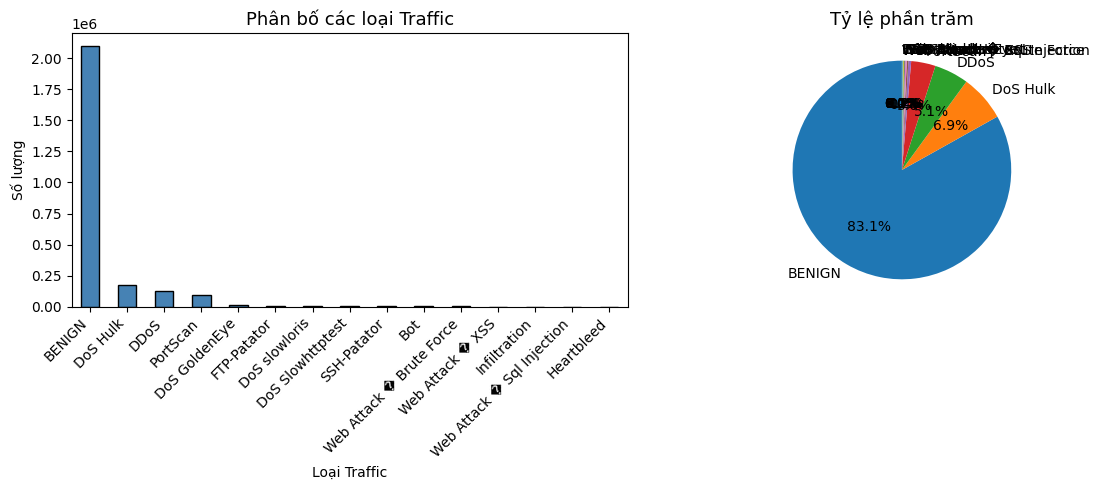

✅ Đã lưu biểu đồ: attack_distribution.png


In [19]:
# ============================================================
# CELL 6: EDA - Xem phân bố các loại traffic
# ============================================================

print("📊 Phân bố nhãn (Label):")
label_counts = df['Label'].value_counts()
print(label_counts)

# Vẽ biểu đồ
plt.figure(figsize=(12, 5))

# Biểu đồ bar
plt.subplot(1, 2, 1)
label_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Phân bố các loại Traffic', fontsize=13)
plt.xlabel('Loại Traffic')
plt.ylabel('Số lượng')
plt.xticks(rotation=45, ha='right')

# Biểu đồ pie (bỏ nhãn nhỏ cho gọn)
plt.subplot(1, 2, 2)
label_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Tỷ lệ phần trăm', fontsize=13)
plt.ylabel('')

plt.tight_layout()
plt.savefig('attack_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Đã lưu biểu đồ: attack_distribution.png")

✅ Số features đã chọn: 18
📋 Danh sách features:
    1. Destination Port
    2. Flow Duration
    3. Total Fwd Packets
    4. Total Backward Packets
    5. Total Length of Fwd Packets
    6. Total Length of Bwd Packets
    7. Fwd Packet Length Mean
    8. Bwd Packet Length Mean
    9. Flow Bytes/s
   10. Flow Packets/s
   11. Packet Length Mean
   12. Packet Length Std
   13. SYN Flag Count
   14. ACK Flag Count
   15. FIN Flag Count
   16. RST Flag Count
   17. PSH Flag Count
   18. URG Flag Count

⏳ Đang vẽ Correlation Heatmap...


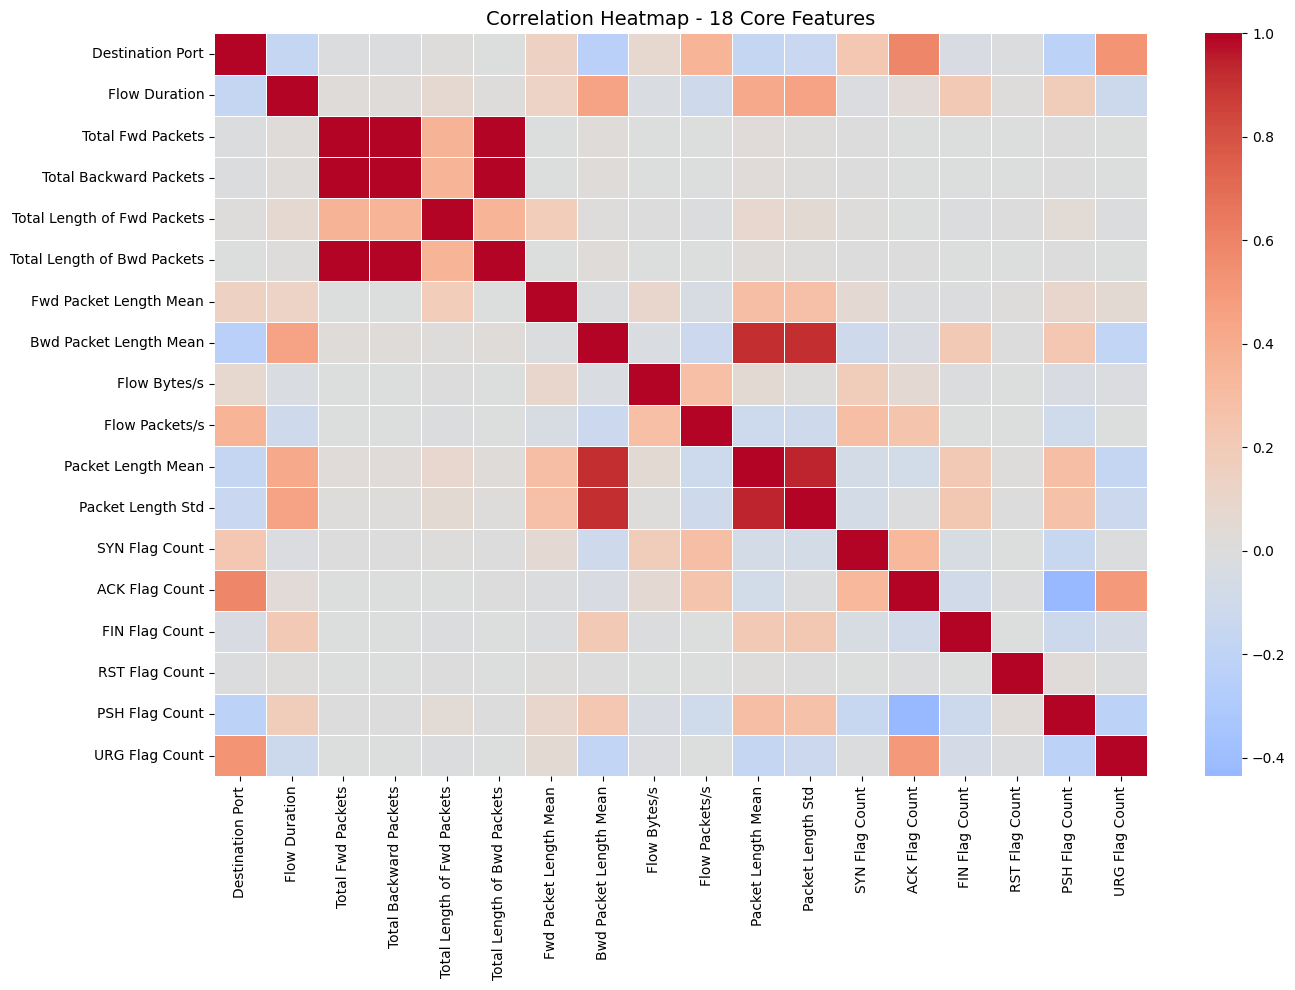

✅ Đã lưu biểu đồ: correlation_heatmap.png


In [20]:
# ============================================================
# CELL 7: Cập nhật lại tên features đúng với dataset
# ============================================================

selected_features = [
    'Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Mean',
    'Bwd Packet Length Mean', 'Flow Bytes/s', 'Flow Packets/s',
    'Packet Length Mean', 'Packet Length Std', 'SYN Flag Count',
    'ACK Flag Count', 'FIN Flag Count', 'RST Flag Count',
    'PSH Flag Count', 'URG Flag Count'
]

print(f"✅ Số features đã chọn: {len(selected_features)}")
print("📋 Danh sách features:")
for i, f in enumerate(selected_features, 1):
    print(f"   {i:2d}. {f}")

# Vẽ Correlation Heatmap
print("\n⏳ Đang vẽ Correlation Heatmap...")
plt.figure(figsize=(14, 10))
corr_matrix = df[selected_features].corr()
sns.heatmap(
    corr_matrix,
    annot=False,
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.title('Correlation Heatmap - 18 Core Features', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Đã lưu biểu đồ: correlation_heatmap.png")

In [21]:
# ============================================================
# CELL 8: Encode Label + Scale features
# ============================================================
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# 1. Tách features và label
X = df[selected_features]
y = df['Label']

# 2. Encode nhãn (chuyển text → số)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("📋 Mapping nhãn:")
for i, label in enumerate(le.classes_):
    print(f"   {i:2d} → {label}")

# 3. Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=selected_features)

print(f"\n✅ Encode và Scale xong!")
print(f"   Shape X: {X_scaled.shape}")
print(f"   Shape y: {y_encoded.shape}")

📋 Mapping nhãn:
    0 → BENIGN
    1 → Bot
    2 → DDoS
    3 → DoS GoldenEye
    4 → DoS Hulk
    5 → DoS Slowhttptest
    6 → DoS slowloris
    7 → FTP-Patator
    8 → Heartbleed
    9 → Infiltration
   10 → PortScan
   11 → SSH-Patator
   12 → Web Attack � Brute Force
   13 → Web Attack � Sql Injection
   14 → Web Attack � XSS

✅ Encode và Scale xong!
   Shape X: (2522362, 18)
   Shape y: (2522362,)


In [22]:
# ============================================================
# CELL 9: Chia tập Train / Test
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded  # Giữ tỷ lệ các class
)

print(f"✅ Chia dữ liệu xong!")
print(f"   Train: {X_train.shape[0]:,} dòng")
print(f"   Test:  {X_test.shape[0]:,} dòng")

✅ Chia dữ liệu xong!
   Train: 2,017,889 dòng
   Test:  504,473 dòng


In [23]:
# ============================================================
# CELL 10: Cân bằng dữ liệu (SMOTE + RandomUnderSampler)
# ============================================================
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from collections import Counter

print("⏳ Đang cân bằng dữ liệu (có thể mất 3-5 phút)...")
print(f"   Phân bố trước: {dict(list(Counter(y_train).items())[:5])} ...")

# Đếm số lượng class lớn nhất
max_count = Counter(y_train).most_common(1)[0][1]

# SMOTE: Tăng minority class lên 10% của majority class
smote_strategy = {
    cls: max(count, int(max_count * 0.1))
    for cls, count in Counter(y_train).items()
    if count < int(max_count * 0.1)
}

# Pipeline: SMOTE → RandomUnderSampler
pipeline = Pipeline([
    ('smote', SMOTE(sampling_strategy=smote_strategy, random_state=42, k_neighbors=3)),
    ('under', RandomUnderSampler(sampling_strategy={
        list(Counter(y_train).most_common(1))[0][0]: int(max_count * 0.5)
    }, random_state=42))
])

X_train_bal, y_train_bal = pipeline.fit_resample(X_train, y_train)

print(f"\n✅ Cân bằng xong!")
print(f"   Train trước: {len(y_train):,} dòng")
print(f"   Train sau:   {len(y_train_bal):,} dòng")
print(f"   Phân bố sau: {Counter(y_train_bal)}")

⏳ Đang cân bằng dữ liệu (có thể mất 3-5 phút)...
   Phân bố trước: {np.int64(4): 138279, np.int64(0): 1677187, np.int64(10): 72655, np.int64(2): 102413, np.int64(12): 1176} ...

✅ Cân bằng xong!
   Train trước: 2,017,889 dòng
   Train sau:   3,186,645 dòng
   Phân bố sau: Counter({np.int64(0): 838593, np.int64(1): 167718, np.int64(2): 167718, np.int64(3): 167718, np.int64(4): 167718, np.int64(5): 167718, np.int64(6): 167718, np.int64(7): 167718, np.int64(8): 167718, np.int64(9): 167718, np.int64(10): 167718, np.int64(11): 167718, np.int64(12): 167718, np.int64(13): 167718, np.int64(14): 167718})


In [24]:
# ============================================================
# CELL 10B (FIX): Sample 20% để train nhanh hơn
# ============================================================
import numpy as np
from collections import Counter

print("⏳ Đang sample 20% dữ liệu...")

# Lấy 20% từ tập đã balance
sample_size = int(len(X_train_bal) * 0.2)
idx = np.random.RandomState(42).choice(len(X_train_bal), sample_size, replace=False)

# Dùng iloc nếu là DataFrame, dùng index trực tiếp nếu là numpy array
if hasattr(X_train_bal, 'iloc'):
    X_train_sample = X_train_bal.iloc[idx]
else:
    X_train_sample = X_train_bal[idx]

if hasattr(y_train_bal, 'iloc'):
    y_train_sample = y_train_bal.iloc[idx]
else:
    y_train_sample = y_train_bal[idx]

print(f"✅ Sample xong!")
print(f"   Train đầy đủ: {len(X_train_bal):,} dòng")
print(f"   Train sample: {len(X_train_sample):,} dòng (20%)")
print(f"   Phân bố: {Counter(y_train_sample)}")

⏳ Đang sample 20% dữ liệu...
✅ Sample xong!
   Train đầy đủ: 3,186,645 dòng
   Train sample: 637,329 dòng (20%)
   Phân bố: Counter({np.int64(0): 167831, np.int64(4): 33772, np.int64(14): 33744, np.int64(10): 33638, np.int64(8): 33619, np.int64(7): 33588, np.int64(2): 33580, np.int64(11): 33567, np.int64(13): 33516, np.int64(6): 33516, np.int64(1): 33484, np.int64(12): 33411, np.int64(5): 33382, np.int64(9): 33368, np.int64(3): 33313})


In [ ]:
# ============================================================
# CELL 11: Import các model ML - Nếu đã có train model r thì xuống step 18B
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import time
import joblib

# Dictionary lưu kết quả các model
results = {}

print("✅ Import xong! Sẵn sàng train models.")
print("\n📋 Thứ tự train:")
print("   1. Naive Bayes      (~vài giây)")
print("   2. Logistic Regression (~vài phút)")
print("   3. KNN              (~ 20 phút)")
print("   4. SVM              (~10-20 phút)")
print("   5. Random Forest    (~5-10 phút)")

✅ Import xong! Sẵn sàng train models.

📋 Thứ tự train:
   1. Naive Bayes      (~vài giây)
   2. Logistic Regression (~vài phút)
   3. KNN              (~ 30 phút)
   4. SVM              (~10-20 phút)
   5. Random Forest    (~5-10 phút)


In [ ]:
# ============================================================
# CELL 12: Model 1 - Naive Bayes
# ============================================================
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report
import time

results = {}
print("🤖 Training Naive Bayes...")
start = time.time()

nb = GaussianNB()
nb.fit(X_train_sample, y_train_sample)
y_pred_nb = nb.predict(X_test)

elapsed = time.time() - start
results['Naive Bayes'] = y_pred_nb
print(f"⏱️ Thời gian: {elapsed:.1f}s")
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred_nb, target_names=le.classes_))

🤖 Training Naive Bayes...
⏱️ Thời gian: 1.1s

📊 Classification Report:
                            precision    recall  f1-score   support

                    BENIGN       1.00      0.21      0.35    419297
                       Bot       0.00      0.77      0.01       391
                      DDoS       0.48      0.19      0.27     25603
             DoS GoldenEye       0.03      0.96      0.06      2057
                  DoS Hulk       0.99      0.37      0.54     34570
          DoS Slowhttptest       0.00      0.09      0.01      1046
             DoS slowloris       0.04      0.59      0.08      1077
               FTP-Patator       0.70      0.99      0.82      1187
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       0.00      0.86      0.00         7
                  PortScan       0.51      0.99      0.68     18164
               SSH-Patator       0.35      0.92      0.51       644
  Web Attack � Brute Force       0.00      0

In [ ]:
# ============================================================
# CELL 13: Model 2 - Logistic Regression
# ============================================================
from sklearn.linear_model import LogisticRegression

print("🤖 Training Logistic Regression...")
start = time.time()

lr = LogisticRegression(max_iter=200, random_state=42, n_jobs=-1, solver='saga', tol=1e-3)
lr.fit(X_train_sample, y_train_sample)
y_pred_lr = lr.predict(X_test)

elapsed = time.time() - start
results['Logistic Regression'] = y_pred_lr
print(f"⏱️ Thời gian: {elapsed:.1f}s")
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

🤖 Training Logistic Regression...
⏱️ Thời gian: 277.2s

📊 Classification Report:
                            precision    recall  f1-score   support

                    BENIGN       1.00      0.76      0.87    419297
                       Bot       0.15      0.39      0.22       391
                      DDoS       0.54      0.91      0.68     25603
             DoS GoldenEye       0.37      0.81      0.51      2057
                  DoS Hulk       0.86      0.91      0.89     34570
          DoS Slowhttptest       0.05      0.77      0.09      1046
             DoS slowloris       0.26      0.57      0.36      1077
               FTP-Patator       0.06      0.31      0.10      1187
                Heartbleed       0.05      1.00      0.10         2
              Infiltration       0.00      0.71      0.01         7
                  PortScan       0.69      0.96      0.80     18164
               SSH-Patator       0.04      0.92      0.08       644
  Web Attack � Brute Force       0

In [ ]:
# ============================================================
# CELL 14: Model 3 - KNN
# ============================================================
from sklearn.neighbors import KNeighborsClassifier

print("🤖 Training KNN...")
start = time.time()

knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train_sample, y_train_sample)
y_pred_knn = knn.predict(X_test)

elapsed = time.time() - start
results['KNN'] = y_pred_knn
print(f"⏱️ Thời gian: {elapsed:.1f}s")
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred_knn, target_names=le.classes_))

🤖 Training KNN...
⏱️ Thời gian: 2129.0s

📊 Classification Report:
                            precision    recall  f1-score   support

                    BENIGN       1.00      0.97      0.98    419297
                       Bot       0.15      0.94      0.26       391
                      DDoS       0.99      1.00      1.00     25603
             DoS GoldenEye       0.77      0.99      0.87      2057
                  DoS Hulk       0.99      0.99      0.99     34570
          DoS Slowhttptest       0.90      0.99      0.94      1046
             DoS slowloris       0.91      0.99      0.95      1077
               FTP-Patator       0.98      0.99      0.98      1187
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       0.04      0.71      0.07         7
                  PortScan       0.78      0.98      0.87     18164
               SSH-Patator       0.73      0.99      0.84       644
  Web Attack � Brute Force       0.09      0.52  

In [ ]:
# ============================================================
# CELL 15: Model 4 - SVM
# ============================================================
from sklearn.svm import LinearSVC

print("🤖 Training SVM...")
start = time.time()

# Dùng LinearSVC thay SVC — nhanh hơn rất nhiều với data lớn
svm = LinearSVC(max_iter=200, random_state=42, tol=1e-3)
svm.fit(X_train_sample, y_train_sample)
y_pred_svm = svm.predict(X_test)

elapsed = time.time() - start
results['SVM'] = y_pred_svm
print(f"⏱️ Thời gian: {elapsed:.1f}s")
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

🤖 Training SVM...
⏱️ Thời gian: 980.6s

📊 Classification Report:
                            precision    recall  f1-score   support

                    BENIGN       1.00      0.78      0.87    419297
                       Bot       0.03      0.45      0.06       391
                      DDoS       0.57      0.99      0.72     25603
             DoS GoldenEye       0.31      0.65      0.42      2057
                  DoS Hulk       0.89      0.89      0.89     34570
          DoS Slowhttptest       0.09      0.79      0.17      1046
             DoS slowloris       0.13      0.56      0.21      1077
               FTP-Patator       0.16      0.99      0.28      1187
                Heartbleed       0.18      1.00      0.31         2
              Infiltration       0.00      0.86      0.01         7
                  PortScan       0.66      0.99      0.79     18164
               SSH-Patator       0.06      0.91      0.11       644
  Web Attack � Brute Force       0.02      0.05   

In [ ]:
# ============================================================
# CELL 16: Model 5 - Random Forest (Best Model)
# ============================================================
from sklearn.ensemble import RandomForestClassifier

print("🤖 Training Random Forest...")
start = time.time()

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_sample, y_train_sample)
y_pred_rf = rf.predict(X_test)

elapsed = time.time() - start
results['Random Forest'] = y_pred_rf
print(f"⏱️ Thời gian: {elapsed:.1f}s")
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

🤖 Training Random Forest...
⏱️ Thời gian: 162.2s

📊 Classification Report:
                            precision    recall  f1-score   support

                    BENIGN       1.00      0.99      0.99    419297
                       Bot       0.31      0.85      0.45       391
                      DDoS       1.00      1.00      1.00     25603
             DoS GoldenEye       0.95      0.99      0.97      2057
                  DoS Hulk       0.99      1.00      0.99     34570
          DoS Slowhttptest       0.97      0.99      0.98      1046
             DoS slowloris       0.99      0.99      0.99      1077
               FTP-Patator       1.00      1.00      1.00      1187
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       0.83      0.71      0.77         7
                  PortScan       0.99      1.00      0.99     18164
               SSH-Patator       0.92      0.99      0.96       644
  Web Attack � Brute Force       0.10   

⏳ Đang vẽ Confusion Matrix...


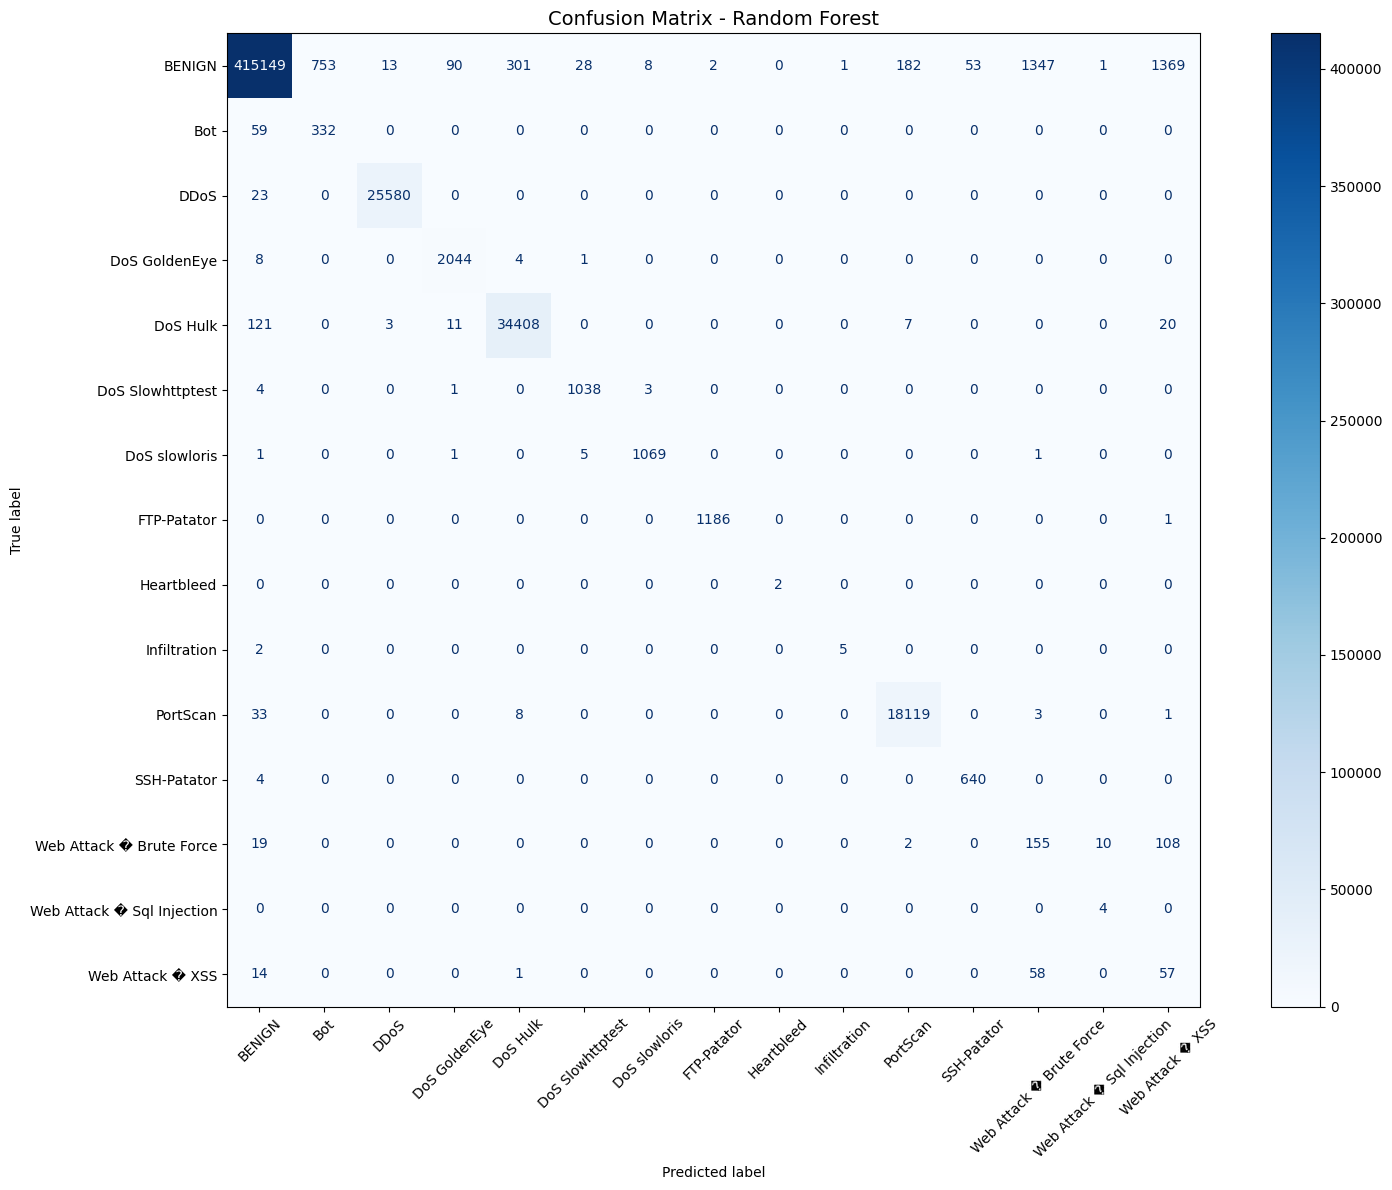

✅ Đã lưu: confusion_matrix_rf.png


In [ ]:
# ============================================================
# CELL 17: Vẽ Confusion Matrix cho Random Forest
# ============================================================
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("⏳ Đang vẽ Confusion Matrix...")

fig, ax = plt.subplots(figsize=(16, 12))
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)
disp.plot(ax=ax, colorbar=True, xticks_rotation=45, cmap='Blues')
plt.title('Confusion Matrix - Random Forest', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrix_rf.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Đã lưu: confusion_matrix_rf.png")

In [ ]:
# ============================================================
# CELL 18: Lưu model Random Forest + scaler + label encoder
# ============================================================
import joblib

print("💾 Đang lưu model...")

# Lưu model
joblib.dump(rf, 'random_forest_ids.pkl')
print("   ✅ Lưu model: random_forest_ids.pkl")

# Lưu scaler
joblib.dump(scaler, 'scaler.pkl')
print("   ✅ Lưu scaler: scaler.pkl")

# Lưu label encoder
joblib.dump(le, 'label_encoder.pkl')
print("   ✅ Lưu label encoder: label_encoder.pkl")

# Kiểm tra kích thước file
import os
size = os.path.getsize('random_forest_ids.pkl') / 1024**2
print(f"\n📦 Kích thước model: {size:.1f} MB")
print("✅ Lưu xong tất cả!")

💾 Đang lưu model...
   ✅ Lưu model: random_forest_ids.pkl
   ✅ Lưu scaler: scaler.pkl
   ✅ Lưu label encoder: label_encoder.pkl

📦 Kích thước model: 448.6 MB
✅ Lưu xong tất cả!


In [ ]:
# CELL: Copy model lên Google Drive
import shutil

drive_path = '/content/drive/MyDrive/IDS_Dataset/'

shutil.copy('random_forest_ids.pkl', drive_path + 'random_forest_ids.pkl')
shutil.copy('scaler.pkl', drive_path + 'scaler.pkl')
shutil.copy('label_encoder.pkl', drive_path + 'label_encoder.pkl')

print("✅ Đã lưu model lên Google Drive!")
print(f"📁 Đường dẫn: {drive_path}")

✅ Đã lưu model lên Google Drive!
📁 Đường dẫn: /content/drive/MyDrive/IDS_Dataset/


In [28]:
# ============================================================
# CELL 18B: Load model từ file .pkl (không cần train lại)
# ============================================================
import joblib
import datetime
import random
import time
import pandas as pd
import os

drive_path = '/content/drive/MyDrive/IDS_Dataset/'

rf = joblib.load(drive_path + 'random_forest_ids.pkl')
scaler = joblib.load(drive_path + 'scaler.pkl')
le = joblib.load(drive_path + 'label_encoder.pkl')


print("✅ Load model xong!")
print(f"   Classes: {le.classes_}")

✅ Load model xong!
   Classes: ['BENIGN' 'Bot' 'DDoS' 'DoS GoldenEye' 'DoS Hulk' 'DoS Slowhttptest'
 'DoS slowloris' 'FTP-Patator' 'Heartbleed' 'Infiltration' 'PortScan'
 'SSH-Patator' 'Web Attack � Brute Force' 'Web Attack � Sql Injection'
 'Web Attack � XSS']


In [29]:
# ============================================================
# CELL 19: Real-time Alert Generation
# ============================================================

def analyze_flow(row_scaled, model, label_encoder, log_file='/content/alerts.log'):
    """
    Phân tích một luồng mạng và tạo cảnh báo nếu phát hiện tấn công
    """
    prediction = model.predict([row_scaled])[0]
    label = label_encoder.inverse_transform([prediction])[0]

    timestamp = datetime.datetime.now().strftime('%Y-%m-%dT%H:%M:%S')
    src_ip = f"192.168.{random.randint(1,255)}.{random.randint(1,255)}"
    dst_ip = f"10.0.{random.randint(1,255)}.{random.randint(1,255)}"
    dst_port = random.choice([80, 443, 22, 21, 8080])

    if label != 'BENIGN':
        alert_msg = (
            f"[ALERT] {timestamp} "
            f"| Suspicious traffic detected: {label} "
            f"| SRC: {src_ip} → DST: {dst_ip}:{dst_port} "
            f"| Severity: HIGH"
        )
        # In ra console
        print(alert_msg)
        # Chỉ ghi vào log khi là tấn công
        with open(log_file, 'a') as f:
            f.write(alert_msg + '\n')
    else:
        # Chỉ in ra console, không ghi log
        print(f"[INFO] {timestamp} | Traffic BENIGN | SRC: {src_ip} → DST: {dst_ip}:{dst_port}")

    return label

print("✅ Hàm analyze_flow đã sẵn sàng!")

✅ Hàm analyze_flow đã sẵn sàng!


In [30]:
# ============================================================
# CELL 20 (FINAL): Mô phỏng real-time traffic
# ============================================================
# Xóa file log cũ
import os
if os.path.exists('/content/alerts.log'):
    os.remove('/content/alerts.log')
print("✅ Đã xóa file log cũ!")

print("🚀 Bắt đầu mô phỏng real-time network traffic...\n")
print("=" * 70)

# Lấy 5 mẫu tấn công + 3 mẫu BENIGN
attack_indices = [i for i, label in enumerate(y_test) if label != 0]
benign_indices = [i for i, label in enumerate(y_test) if label == 0]
sample_indices = random.sample(attack_indices, 5) + random.sample(benign_indices, 3)
random.shuffle(sample_indices)

for idx in sample_indices:
    if hasattr(X_test, 'iloc'):
        row = X_test.iloc[idx].values
    else:
        row = X_test[idx]

    analyze_flow(row, rf, le, log_file=log_file)
    time.sleep(0.3)

print("=" * 70)

# Đọc và hiển thị log
print("\n📄 Nội dung file alerts.log:")
print("=" * 70)
with open(log_file, 'r') as f:
    print(f.read())
print("=" * 70)
print("✅ Hoàn thành!")

✅ Đã xóa file log cũ!
🚀 Bắt đầu mô phỏng real-time network traffic...

[INFO] 2026-05-04T06:41:14 | Traffic BENIGN | SRC: 192.168.106.168 → DST: 10.0.132.93:8080
[ALERT] 2026-05-04T06:41:14 | Suspicious traffic detected: DoS Hulk | SRC: 192.168.106.121 → DST: 10.0.23.176:80 | Severity: HIGH
[INFO] 2026-05-04T06:41:15 | Traffic BENIGN | SRC: 192.168.103.72 → DST: 10.0.9.202:80
[ALERT] 2026-05-04T06:41:15 | Suspicious traffic detected: DoS GoldenEye | SRC: 192.168.87.222 → DST: 10.0.107.63:443 | Severity: HIGH
[ALERT] 2026-05-04T06:41:15 | Suspicious traffic detected: DoS Hulk | SRC: 192.168.198.95 → DST: 10.0.10.73:443 | Severity: HIGH
[ALERT] 2026-05-04T06:41:16 | Suspicious traffic detected: DDoS | SRC: 192.168.225.116 → DST: 10.0.174.69:22 | Severity: HIGH
[ALERT] 2026-05-04T06:41:16 | Suspicious traffic detected: DDoS | SRC: 192.168.180.9 → DST: 10.0.199.66:22 | Severity: HIGH
[INFO] 2026-05-04T06:41:16 | Traffic BENIGN | SRC: 192.168.151.159 → DST: 10.0.251.195:80

📄 Nội dung file 